In [2]:
import polars as pl
import numpy as np

In [3]:
from matplotlib import pyplot as plt

In [4]:
# !uv pip show polars

In [5]:
df = pl.read_csv("../data/stockdata3.csv")

In [6]:
stocks = [c for c in df.columns if c != "day" and c != "timestr"]

In [7]:
df

day,timestr,a,b,c,d,e,f
i64,str,f64,f64,f64,f64,f64,f64
1,"""09:30:00""",325.45,13.795,94.5,49.985,49.93,17.025
1,"""09:31:00""",325.245,13.89,94.515,49.99,49.96,17.025
1,"""09:32:00""",325.58,13.905,94.565,49.995,49.96,17.025
1,"""09:33:00""",325.47,13.955,94.645,50.065,49.92,17.025
1,"""09:34:00""",325.295,13.975,94.58,50.03,49.9,17.025
…,…,…,…,…,…,…,…
362,"""15:56:00""",404.825,5.515,45.352,45.305,43.57,10.745
362,"""15:57:00""",404.815,5.615,45.362,45.795,43.61,10.745
362,"""15:58:00""",404.915,5.625,45.352,45.805,43.63,10.755


In [8]:
df.describe()

statistic,day,timestr,a,b,c,d,e,f
str,f64,str,f64,f64,f64,f64,f64,f64
"""count""",98352.0,"""98352""",98281.0,98352.0,98321.0,98334.0,98352.0,96981.0
"""null_count""",0.0,"""0""",71.0,0.0,31.0,18.0,0.0,1371.0
"""mean""",181.29732,null,363.767737,10.048836,69.44557,49.803747,47.727738,13.204838
"""std""",104.61705,null,28.281333,3.332643,28.675762,4.539923,7.053875,2.404705
"""min""",1.0,"""09:30:00""",0.0,4.885,33.807,1.0,38.55,9.365
"""25%""",89.0,null,341.785,6.605,45.33,46.175,42.04,10.945
"""50%""",180.0,null,357.915,10.595,50.96,50.105,45.41,13.325
"""75%""",271.0,null,387.89,13.465,101.905,53.735,51.35,15.035
"""max""",362.0,"""16:00:00""",426.56,15.335,116.385,62.137,69.21,18.815


In [ ]:
df = df.with_columns(
    (pl.date(2000, 1, 1) + pl.duration(days=pl.col("day") - 1))
    .dt.combine(pl.col("timestr").str.to_time("%H:%M:%S"))
    .alias("datetime")
)
df.select("day", "timestr", "datetime")
df = df.with_row_index() if "index" not in df.columns else df

DuplicateError: column with name 'index' has more than one occurrence

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=len(stocks),
    cols=2,
    shared_xaxes=True,
    column_widths=[0.72, 0.28],
    horizontal_spacing=0.07,
    vertical_spacing=0.04,
    subplot_titles=[
        title for s in stocks for title in (f"ts for {s}", f"hist for {s}")
    ],
)

datetime = df["datetime"].to_numpy()
for row, s in enumerate(stocks, start=1):
    values = df[s].to_numpy()
    fig.add_trace(
        go.Scattergl(x=datetime, y=values, line_shape="hv", name=s, showlegend=False),
        row=row,
        col=1,
    )
    fig.add_trace(
        go.Histogram(x=values, nbinsx=100, name=s, showlegend=False),
        row=row,
        col=2,
    )

fig.update_layout(
    height=260 * len(stocks),
    title_text="Stock time series & distributions",
    margin=dict(t=60),
)
fig.show()


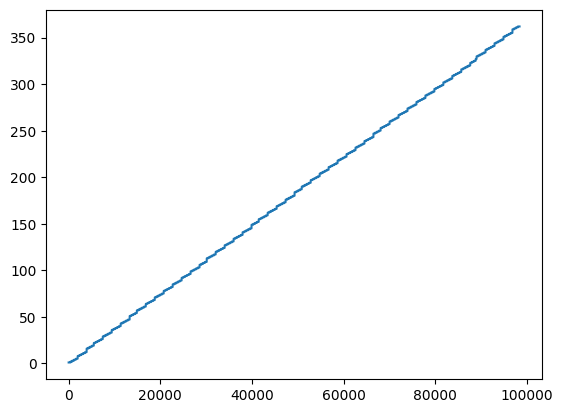

In [ ]:
plt.plot(df["day"])

In [ ]:
df["day"].diff().value_counts()

day,count
i64,u32
3,44
1,199
0,98100
2,1
null,1
4,7


In [26]:
for s in stocks:
    null_df_s = df.filter(pl.col(s).is_null())
    display(null_df_s)
    print(s, len(null_df_s))
    # plt.hist(null_df_s['index'].diff())

index,day,timestr,a,b,c,d,e,f
u32,i64,str,f64,f64,f64,f64,f64,f64
16523,61,"""11:11:00""",null,14.125,103.395,53.595,55.17,14.605
21115,79,"""09:31:00""",null,13.995,107.18,53.82,61.53,14.495
21116,79,"""09:32:00""",null,13.995,107.16,53.785,61.54,14.495
21117,79,"""09:33:00""",null,14.075,107.315,53.915,61.62,14.495
21118,79,"""09:34:00""",null,13.975,107.125,53.995,61.59,14.495
…,…,…,…,…,…,…,…,…
76244,281,"""16:00:00""",null,6.335,39.578,43.185,40.52,11.175
77069,284,"""10:12:00""",null,6.235,40.56,43.34,40.45,11.635
78616,290,"""09:55:00""",null,6.805,41.813,43.915,39.54,11.605


a 71


index,day,timestr,a,b,c,d,e,f
u32,i64,str,f64,f64,f64,f64,f64,f64


b 0


index,day,timestr,a,b,c,d,e,f
u32,i64,str,f64,f64,f64,f64,f64,f64
31783,117,"""11:22:00""",349.67,12.4,null,null,51.19,15.515
31784,117,"""11:23:00""",349.735,12.4,null,null,51.22,15.515
31785,117,"""11:24:00""",349.72,12.4,null,null,51.23,15.515
31786,117,"""11:25:00""",349.78,12.295,null,null,51.17,15.515
31787,117,"""11:26:00""",349.845,12.295,null,null,51.12,15.515
…,…,…,…,…,…,…,…,…
46331,171,"""12:43:00""",326.005,10.9,null,null,45.24,13.455
46332,171,"""12:44:00""",326.22,10.8,null,null,45.22,13.455
74331,275,"""10:11:00""",373.88,5.225,null,37.6,40.98,9.805


...

d 18


index,day,timestr,a,b,c,d,e,f
u32,i64,str,f64,f64,f64,f64,f64,f64


e 0


index,day,timestr,a,b,c,d,e,f
u32,i64,str,f64,f64,f64,f64,f64,f64
1865,5,"""14:31:00""",333.84,14.205,93.45,49.635,49.57,null
1866,5,"""14:32:00""",333.89,14.105,93.435,49.655,49.51,null
1867,5,"""14:33:00""",333.85,14.115,93.45,49.635,49.56,null
1868,5,"""14:34:00""",333.905,14.215,93.47,49.645,49.62,null
1869,5,"""14:35:00""",333.975,14.125,93.44,49.635,49.73,null
…,…,…,…,…,…,…,…,…
97317,360,"""11:48:00""",404.575,5.355,44.685,45.565,43.12,null
97318,360,"""11:49:00""",404.55,5.365,44.75,45.585,43.11,null
97319,360,"""11:50:00""",404.77,5.265,44.767,45.57,43.14,null


f 1371


In [ ]:
df = df.with_columns(
    [(pl.col(s).diff() / pl.col(s) * 1e4).alias(f"r{s}") for s in stocks]
)
returns = [f"r{s}" for s in stocks]

In [22]:
df.describe()

statistic,day,timestr,a,b,c,d,e,f,ra,rb,rc,rd,re,rf
str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",98352.0,"""98352""",98269.0,98351.0,98311.0,98329.0,98351.0,96968.0,98257.0,98350.0,98302.0,98325.0,98350.0,96955.0
"""null_count""",0.0,"""0""",83.0,1.0,41.0,23.0,1.0,1384.0,95.0,2.0,50.0,27.0,2.0,1397.0
"""mean""",181.29732,null,-inf,-0.465912,-0.113184,-450.607093,-0.019136,-0.047296,NaN,NaN,NaN,NaN,NaN,NaN
"""std""",104.61705,null,NaN,86.521435,33.17567,14953.331271,10.459731,11.769333,NaN,NaN,NaN,NaN,NaN,NaN
"""min""",1.0,"""09:30:00""",-inf,-991.174474,-9636.53431,-549050.0,-298.350298,-1017.347839,-inf,-inf,-inf,-inf,-inf,-inf
"""25%""",89.0,null,-2.932306,-55.420852,-4.50676,-4.402862,-6.55308,0.0,618.946976,10000.0,1.913692,5.439217,2.233639,NaN
"""50%""",180.0,null,0.0,0.0,0.0,0.0,0.0,0.0,10277.650186,18183.295824,10000.0,10000.0,10000.0,NaN
"""75%""",271.0,null,2.973978,54.326737,4.444225,4.379722,6.524576,0.0,20943.090526,26589.416763,20002.344006,20627.811838,20002.562132,NaN
"""max""",362.0,"""16:00:00""",10000.0,1445.051609,452.769227,9821.061108,248.486779,611.961057,inf,inf,inf,inf,inf,inf


In [20]:
df.select(returns).describe()

statistic,ra,rb,rc,rd,re,rf
str,f64,f64,f64,f64,f64,f64
"""count""",98257.0,98350.0,98302.0,98325.0,98350.0,96955.0
"""null_count""",95.0,2.0,50.0,27.0,2.0,1397.0
"""mean""",NaN,NaN,NaN,NaN,NaN,NaN
"""std""",NaN,NaN,NaN,NaN,NaN,NaN
"""min""",-inf,-inf,-inf,-inf,-inf,-inf
"""25%""",618.946976,10000.0,1.913692,5.439217,2.233639,NaN
"""50%""",10277.650186,18183.295824,10000.0,10000.0,10000.0,NaN
"""75%""",20943.090526,26589.416763,20002.344006,20627.811838,20002.562132,NaN
"""max""",inf,inf,inf,inf,inf,inf


ValueError: supplied range of [-inf, inf] is not finite

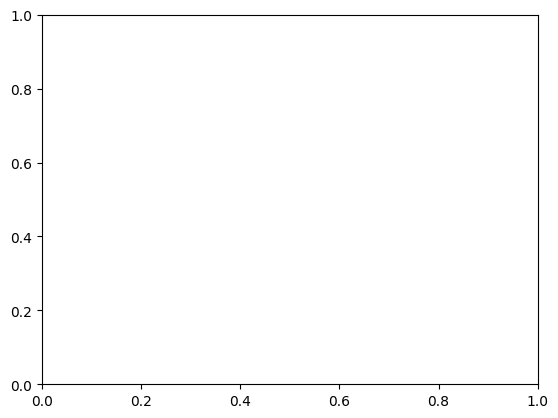

In [ ]:
for r in returns:
    plt.hist(df[r])

In [ ]:
df = df.with_columns(pl.col(pl.Float64).fill_nan(None))